# CSE428 Project -


## 1. Imports

In [ ]:
import math
import random
import tarfile
import urllib.request
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms, models
from torchvision.transforms import functional as TF

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from tqdm.auto import tqdm

print("torch:", torch.__version__, "| torchvision:", torchvision.__version__)

from IPython.display import display, Markdown


torch: 2.11.0+cpu | torchvision: 0.26.0+cpu


## 2. Configuration



In [ ]:
ACTIVE_STAGE = "demo"

VALID_STAGES = {"audit", "base", "attention", "augmentation", "mobilenet", "efficientnet", "densenet", "final", "demo"}

if ACTIVE_STAGE not in VALID_STAGES:
    raise ValueError(f"Invalid stage: {ACTIVE_STAGE}. Choose from {sorted(VALID_STAGES)}")

IMG_SIZE = 128
BATCH_SIZE = 32
NUM_WORKERS = 0
BASE_CH = 32
NUM_EPOCHS = 15
CLASSIFIER_EPOCHS = 10
SEED = 42
DEMO_INDEX = 100
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Active stage:", ACTIVE_STAGE)
print("Using device:", DEVICE)

if DEVICE.type == "cpu":
    print("WARNING: No GPU detected. In Colab, select Runtime > Change runtime type > GPU.")

try:
    from google.colab import drive

    drive.mount("/content/drive")
    ARTIFACT_DIR = Path("/content/drive/MyDrive/CSE428_Project_Artifacts")
except ImportError:
    ARTIFACT_DIR = Path("./CSE428_Project_Artifacts")

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

BASE_CHECKPOINT_PATH = ARTIFACT_DIR / "base_unet_best.pth"
BASE_HISTORY_PATH = ARTIFACT_DIR / "base_unet_history.csv"
BASE_REPORT_PATH = ARTIFACT_DIR / "base_unet_report.csv"

ATTENTION_CHECKPOINT_PATH = ARTIFACT_DIR / "attention_unet_best.pth"
ATTENTION_HISTORY_PATH = ARTIFACT_DIR / "attention_unet_history.csv"
ATTENTION_REPORT_PATH = ARTIFACT_DIR / "attention_unet_report.csv"

AUG_ATTENTION_CHECKPOINT_PATH = ARTIFACT_DIR / "bonus2_aug_attention_best.pth"
AUG_ATTENTION_HISTORY_PATH = ARTIFACT_DIR / "bonus2_aug_attention_history.csv"
AUG_ATTENTION_REPORT_PATH = ARTIFACT_DIR / "bonus2_aug_attention_report.csv"

#the lines below are for saving the metrics in our google drive
BONUS1_MODELS = {
    "mobilenet": "MobileNetV2",
    "efficientnet": "EfficientNet-B0",
    "densenet": "DenseNet121",
}

BONUS1_PATHS = {
    stage: {
        "checkpoint": ARTIFACT_DIR / f"bonus1_{stage}_best.pth",
        "history": ARTIFACT_DIR / f"bonus1_{stage}_history.csv",
        "report": ARTIFACT_DIR / f"bonus1_{stage}_report.csv",
    }
    for stage in BONUS1_MODELS
}

print("Artifact directory:", ARTIFACT_DIR)

Active stage: demo
Using device: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Artifact directory: /content/drive/MyDrive/CSE428_Project_Artifacts


## 3. Data acquisition



In [ ]:
DATA_ROOT = Path("./oxford_pet_data")
IMAGES_URL = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz"
ANNOTATIONS_URL = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz"


def download_and_extract(url, dest_dir):
    dest_dir = Path(dest_dir)
    dest_dir.mkdir(parents=True, exist_ok=True)
    fname = dest_dir / Path(url).name
    if not fname.exists():
        print(f"Downloading {url} ...")
        try:
            urllib.request.urlretrieve(url, fname)
        except Exception as exc:
            print(f"Download failed ({exc}). Use an alternate mirror or the provided "
                  f"torrent file, then place '{fname.name}' in '{dest_dir}' and re-run.")
            raise
    else:
        print(f"{fname} already exists, skipping download.")

    print(f"Extracting {fname} ...")
    with tarfile.open(fname) as tar:
        tar.extractall(path=dest_dir)


if ACTIVE_STAGE != "demo":
    download_and_extract(IMAGES_URL, DATA_ROOT)

download_and_extract(ANNOTATIONS_URL, DATA_ROOT)

IMAGES_DIR = DATA_ROOT / "images"
ANNOTATIONS_DIR = DATA_ROOT / "annotations"
TRIMAPS_DIR = ANNOTATIONS_DIR / "trimaps"

print(sorted(p.name for p in DATA_ROOT.glob("*")))


oxford_pet_data/annotations.tar.gz already exists, skipping download.
Extracting oxford_pet_data/annotations.tar.gz ...


/tmp/ipykernel_950/3753793323.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=dest_dir)


['annotations', 'annotations.tar.gz', 'images', 'images.tar.gz']


## 4. Metadata parsing


In [ ]:
def parse_list_file(path):
    records = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            image_name = parts[0]
            class_id, species_id, breed_id = int(parts[1]), int(parts[2]), int(parts[3])
            name_part = image_name.rsplit("_", 1)[0]
            breed_name = " ".join(w.capitalize() for w in name_part.split("_"))
            species_name = "Cat" if species_id == 1 else "Dog"
            records.append({
                "image_name": image_name,
                "class_id": class_id,
                "species_id": species_id,
                "species_name": species_name,
                "breed_id": breed_id,
                "breed_name": breed_name,
            })
    return pd.DataFrame(records)


meta_df = parse_list_file(ANNOTATIONS_DIR / "list.txt")
NUM_CLASSES = meta_df["class_id"].nunique()

class_id_to_name = (
    meta_df.drop_duplicates("class_id")
    .set_index("class_id")[["breed_name", "species_name"]]
    .to_dict("index")
)

print(f"Total images: {len(meta_df)} | Number of breed classes: {NUM_CLASSES}")
print("\nSpecies distribution:")
print(meta_df["species_name"].value_counts())
print("\nImages per breed (first 5):")
print(meta_df["breed_name"].value_counts().head())
meta_df.head()


Total images: 7349 | Number of breed classes: 37

Species distribution:
species_name
Dog    4978
Cat    2371
Name: count, dtype: int64

Images per breed (first 5):
breed_name
American Bulldog             200
Basset Hound                 200
American Pit Bull Terrier    200
Beagle                       200
Bengal                       200
Name: count, dtype: int64


,image_name,class_id,species_id,species_name,breed_id,breed_name
0,Abyssinian_100,1,1,Cat,1,Abyssinian
1,Abyssinian_101,1,1,Cat,1,Abyssinian
2,Abyssinian_102,1,1,Cat,1,Abyssinian
3,Abyssinian_103,1,1,Cat,1,Abyssinian
4,Abyssinian_104,1,1,Cat,1,Abyssinian


## 5. Mask utilities



In [ ]:
def load_binary_mask(mask_path):
    # 1=foreground, 2=background, 3=boundary
    trimap = np.array(Image.open(mask_path))
    binary_mask = np.where(trimap == 2, 0, 1).astype(np.uint8)
    return binary_mask


def load_trimap_3class(mask_path):
    # 0-indexed 3-class map: 0=background, 1=foreground, 2=boundary
    trimap = np.array(Image.open(mask_path))
    out = np.zeros_like(trimap, dtype=np.uint8)
    out[trimap == 1] = 1
    out[trimap == 2] = 0
    out[trimap == 3] = 2
    return out


## 6. Dataset class and transforms

In [ ]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])


def denormalize_image(img_tensor):
    img = img_tensor.detach().cpu().numpy().transpose(1, 2, 0)
    img = img * IMAGENET_STD + IMAGENET_MEAN
    return np.clip(img, 0, 1)


class OxfordPetDataset(Dataset):
    def __init__(self, df, images_dir, trimaps_dir, img_size=IMG_SIZE,
                 mask_mode="binary", augment=False):
        self.df = df.reset_index(drop=True)
        self.images_dir = Path(images_dir)
        self.trimaps_dir = Path(trimaps_dir)
        self.img_size = img_size
        self.mask_mode = mask_mode
        self.augment = augment
        self.normalize = transforms.Normalize(mean=IMAGENET_MEAN.tolist(),
                                               std=IMAGENET_STD.tolist())

    def __len__(self):
        return len(self.df)

    def _load_image(self, image_name):
        return Image.open(self.images_dir / f"{image_name}.jpg").convert("RGB")

    def _load_mask(self, image_name):
        mask_path = self.trimaps_dir / f"{image_name}.png"
        if self.mask_mode == "binary":
            mask = load_binary_mask(mask_path)
        else:
            mask = load_trimap_3class(mask_path)
        return Image.fromarray(mask)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_name = row["image_name"]
        img = self._load_image(image_name)
        mask = self._load_mask(image_name)

        img = TF.resize(img, [self.img_size, self.img_size],
                         interpolation=TF.InterpolationMode.BILINEAR)
        mask = TF.resize(mask, [self.img_size, self.img_size],
                          interpolation=TF.InterpolationMode.NEAREST)
        #data augmentation
        if self.augment:
            if random.random() < 0.5:
                img = TF.hflip(img)
                mask = TF.hflip(mask)
            angle = random.uniform(-15, 15)
            img = TF.rotate(img, angle, interpolation=TF.InterpolationMode.BILINEAR)
            mask = TF.rotate(mask, angle, interpolation=TF.InterpolationMode.NEAREST, fill=0)
            if random.random() < 0.3:
                img = transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)(img)

        img_t = self.normalize(TF.to_tensor(img))
        mask_t = torch.as_tensor(np.array(mask), dtype=torch.long)
        class_label = int(row["class_id"]) - 1  # 0-indexed, 0..NUM_CLASSES-1

        return {
            "image": img_t,
            "mask": mask_t,
            "class_label": class_label,
            "image_name": image_name,
        }


## 7. Train / validation / test split and DataLoaders



In [ ]:
trainval_meta = parse_list_file(ANNOTATIONS_DIR / "trainval.txt")
test_meta = parse_list_file(ANNOTATIONS_DIR / "test.txt")

train_df, val_df = train_test_split(
    trainval_meta,
    test_size=0.15,
    random_state=SEED,
    stratify=trainval_meta["class_id"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_meta.reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


def make_loaders(mask_mode="binary", augment_train=False, batch_size=BATCH_SIZE):
    train_ds = OxfordPetDataset(
        train_df, IMAGES_DIR, TRIMAPS_DIR,
        mask_mode=mask_mode, augment=augment_train,
    )

    val_ds = OxfordPetDataset(
        val_df, IMAGES_DIR, TRIMAPS_DIR,
        mask_mode=mask_mode, augment=False,
    )

    test_ds = OxfordPetDataset(
        test_df, IMAGES_DIR, TRIMAPS_DIR,
        mask_mode=mask_mode, augment=False,
    )

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=NUM_WORKERS, drop_last=False,
    )

    train_eval_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=False,
        num_workers=NUM_WORKERS, drop_last=False,
    )

    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=NUM_WORKERS, drop_last=False,
    )

    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=NUM_WORKERS, drop_last=False,
    )

    return (
        train_ds, val_ds, test_ds, train_loader,
        train_eval_loader, val_loader, test_loader,
    )


(train_ds, val_ds, test_ds, train_loader, train_eval_loader, val_loader, test_loader,) = make_loaders(mask_mode="binary", augment_train=False)

Train: 3128 | Val: 552 | Test: 3669


## 8. Dataset exploration - 3x3 grid of random samples with mask overlays

In [ ]:
def overlay_mask_on_image(img_rgb_float, mask, color=(0, 1, 0), alpha=0.45):
    # img_rgb_float in [0,1], HxWx3. mask is HxW, any value > 0 is treated as foreground.
    overlay = img_rgb_float.copy()
    fg = mask > 0
    for c in range(3):
        overlay[..., c] = np.where(fg, overlay[..., c] * (1 - alpha) + color[c] * alpha,
                                    overlay[..., c])
    return overlay


def plot_random_grid(dataset, n=9, seed=None):
    if seed is not None:
        random.seed(seed)
    indices = random.sample(range(len(dataset)), n)
    ncols = 3
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = axes.flatten()
    for ax, idx in zip(axes, indices):
        sample = dataset[idx]
        img = denormalize_image(sample["image"])
        mask = sample["mask"].numpy()
        overlay = overlay_mask_on_image(img, mask)
        row = dataset.df.iloc[idx]
        ax.imshow(overlay)
        ax.set_title(f'{row["breed_name"]} ({row["species_name"]})')
        ax.axis("off")
    for ax in axes[len(indices):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


if ACTIVE_STAGE in {"audit", "final"}:
    plot_random_grid(train_ds, n=9, seed=SEED)


## 9. Evaluation metrics



In [ ]:
def segmentation_metrics(preds, targets, num_classes=2, eps=1e-7):
    if torch.is_tensor(preds):
        preds = preds.detach().cpu().numpy()
    if torch.is_tensor(targets):
        targets = targets.detach().cpu().numpy()

    ious, dices = [], []
    for c in range(num_classes):
        pred_c = (preds == c)
        target_c = (targets == c)
        intersection = np.logical_and(pred_c, target_c).sum()
        union = np.logical_or(pred_c, target_c).sum()
        if union == 0:
            continue
        ious.append(intersection / (union + eps))
        dices.append((2 * intersection) / (pred_c.sum() + target_c.sum() + eps))

    return {
        "mIoU": float(np.mean(ious)) if ious else 0.0,
        "dice": float(np.mean(dices)) if dices else 0.0,
        "pixel_acc": float((preds == targets).sum() / targets.size),
    }


def classification_metrics(preds, targets):
    if torch.is_tensor(preds):
        preds = preds.detach().cpu().numpy()
    if torch.is_tensor(targets):
        targets = targets.detach().cpu().numpy()
    return {
        "accuracy": accuracy_score(targets, preds),
        "precision": precision_score(targets, preds, average="macro", zero_division=0),
        "recall": recall_score(targets, preds, average="macro", zero_division=0),
        "f1": f1_score(targets, preds, average="macro", zero_division=0),
    }


## 10. Model building blocks


In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNetEncoder(nn.Module):
    def __init__(self, in_ch=3, base_ch=32):
        super().__init__()
        self.enc1 = ConvBlock(in_ch, base_ch)
        self.enc2 = ConvBlock(base_ch, base_ch * 2)
        self.enc3 = ConvBlock(base_ch * 2, base_ch * 4)
        self.enc4 = ConvBlock(base_ch * 4, base_ch * 8)
        self.bottleneck = ConvBlock(base_ch * 8, base_ch * 16)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        return e1, e2, e3, e4, b


class ClassifierHead(nn.Module):
    def __init__(self, in_ch, num_classes, hidden=256, dropout=0.3):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_ch, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, bottleneck_feat):
        return self.fc(self.pool(bottleneck_feat))


## 11. Base U-Net (segmentation + classification, joint)




In [ ]:
class UNetDecoder(nn.Module):
    def __init__(self, base_ch=32, out_ch=2):
        super().__init__()
        self.up4 = nn.ConvTranspose2d(base_ch * 16, base_ch * 8, kernel_size=2, stride=2)
        self.dec4 = ConvBlock(base_ch * 16, base_ch * 8)
        self.up3 = nn.ConvTranspose2d(base_ch * 8, base_ch * 4, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(base_ch * 8, base_ch * 4)
        self.up2 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(base_ch * 4, base_ch * 2)
        self.up1 = nn.ConvTranspose2d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(base_ch * 2, base_ch)
        self.out_conv = nn.Conv2d(base_ch, out_ch, kernel_size=1)

    def forward(self, e1, e2, e3, e4, b):
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)


class MultiTaskUNet(nn.Module):
    def __init__(self, in_ch=3, seg_classes=2, num_pet_classes=37, base_ch=32):
        super().__init__()
        self.encoder = UNetEncoder(in_ch, base_ch)
        self.decoder = UNetDecoder(base_ch, seg_classes)
        self.classifier = ClassifierHead(base_ch * 16, num_pet_classes)

    def forward(self, x):
        e1, e2, e3, e4, b = self.encoder(x)
        seg_logits = self.decoder(e1, e2, e3, e4, b)
        class_logits = self.classifier(b)
        return seg_logits, class_logits


## 12. Training utilities (shared by every model trained below)

In [ ]:
def load_model_weights(model, checkpoint_path):
    checkpoint_path = Path(checkpoint_path)

    if not checkpoint_path.is_file():
        raise FileNotFoundError(
            f"Checkpoint not found: {checkpoint_path}\n"
            "Train the corresponding model first."
        )

    try:
        state_dict = torch.load(checkpoint_path, map_location=DEVICE, weights_only=True)
    except TypeError:
        state_dict = torch.load(checkpoint_path, map_location=DEVICE)

    model.load_state_dict(state_dict)
    model.to(DEVICE)
    model.eval()

    print("Loaded checkpoint:", checkpoint_path)
    return model


def save_history(history, path):
    pd.DataFrame(dict(history)).to_csv(path, index=False)
    print("Saved training history:", path)


def load_history(path):
    path = Path(path)

    if not path.is_file():
        print("Training history was not found:", path)
        return None

    history_df = pd.read_csv(path)
    return {column: history_df[column].tolist() for column in history_df.columns}


def run_epoch(
    model, loader, optimizer=None, seg_loss_fn=None, class_loss_fn=None,
    seg_weight=1.0, class_weight=1.0, num_seg_classes=2,
):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_seg_loss = 0.0
    total_class_loss = 0.0
    processed_samples = 0

    all_seg_preds = []
    all_seg_targets = []
    all_class_preds = []
    all_class_targets = []

    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for batch in tqdm(loader, leave=False):
            images = batch["image"].to(DEVICE)
            masks = batch["mask"].to(DEVICE)
            class_labels = batch["class_label"].to(DEVICE)

            if is_train:
                optimizer.zero_grad()

            seg_logits, class_logits = model(images)

            seg_loss = seg_loss_fn(seg_logits, masks)
            class_loss = class_loss_fn(class_logits, class_labels)
            loss = seg_weight * seg_loss + class_weight * class_loss

            if is_train:
                loss.backward()
                optimizer.step()

            batch_size = images.size(0)
            processed_samples += batch_size

            total_loss += loss.item() * batch_size
            total_seg_loss += seg_loss.item() * batch_size
            total_class_loss += class_loss.item() * batch_size

            all_seg_preds.append(torch.argmax(seg_logits, dim=1).cpu())
            all_seg_targets.append(masks.cpu())
            all_class_preds.append(torch.argmax(class_logits, dim=1).cpu())
            all_class_targets.append(class_labels.cpu())

    all_seg_preds = torch.cat(all_seg_preds).numpy()
    all_seg_targets = torch.cat(all_seg_targets).numpy()
    all_class_preds = torch.cat(all_class_preds).numpy()
    all_class_targets = torch.cat(all_class_targets).numpy()

    seg_metrics = segmentation_metrics(
        all_seg_preds,
        all_seg_targets,
        num_classes=num_seg_classes,
    )

    class_metrics = classification_metrics(all_class_preds, all_class_targets)

    return {
        "loss": total_loss / processed_samples,
        "seg_loss": total_seg_loss / processed_samples,
        "class_loss": total_class_loss / processed_samples,
        **{f"seg_{key}": value for key, value in seg_metrics.items()},
        **{f"class_{key}": value for key, value in class_metrics.items()},
    }


def train_model(
    model, train_loader, val_loader, checkpoint_path,
    num_epochs=NUM_EPOCHS, lr=1e-3, num_seg_classes=2,
):
    model.to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    seg_loss_fn = nn.CrossEntropyLoss()
    class_loss_fn = nn.CrossEntropyLoss()

    history = defaultdict(list)
    best_val_loss = float("inf")
    best_epoch = 0

    for epoch in range(1, num_epochs + 1):
        train_metrics = run_epoch(
            model,
            train_loader,
            optimizer=optimizer,
            seg_loss_fn=seg_loss_fn,
            class_loss_fn=class_loss_fn,
            num_seg_classes=num_seg_classes,
        )

        val_metrics = run_epoch(
            model,
            val_loader,
            optimizer=None,
            seg_loss_fn=seg_loss_fn,
            class_loss_fn=class_loss_fn,
            num_seg_classes=num_seg_classes,
        )

        for key, value in train_metrics.items():
            history[f"train_{key}"].append(value)

        for key, value in val_metrics.items():
            history[f"val_{key}"].append(value)

        print(
            f"Epoch {epoch}/{num_epochs} | "
            f"train_loss={train_metrics['loss']:.4f} "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"train_mIoU={train_metrics['seg_mIoU']:.3f} "
            f"val_mIoU={val_metrics['seg_mIoU']:.3f} | "
            f"train_cls_acc={train_metrics['class_accuracy']:.3f} "
            f"val_cls_acc={val_metrics['class_accuracy']:.3f}"
        )

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_epoch = epoch

            torch.save(model.state_dict(), checkpoint_path)

            print(
                f"Saved best model at epoch {epoch} "
                f"with validation loss {best_val_loss:.4f}"
            )

    print(f"Best epoch: {best_epoch} | Best validation loss: {best_val_loss:.4f}")

    load_model_weights(model, checkpoint_path)
    return history


def plot_history(history, title_prefix=""):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(history["train_loss"], label="Train")
    axes[0].plot(history["val_loss"], label="Validation")
    axes[0].set_title(f"{title_prefix} Total Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history["train_seg_mIoU"], label="Train mIoU")
    axes[1].plot(history["val_seg_mIoU"], label="Validation mIoU")
    axes[1].plot(history["train_seg_dice"], label="Train Dice", linestyle="--")
    axes[1].plot(history["val_seg_dice"], label="Validation Dice", linestyle="--")
    axes[1].set_title(f"{title_prefix} Segmentation Metrics")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    axes[2].plot(history["train_class_accuracy"], label="Train accuracy")
    axes[2].plot(history["val_class_accuracy"], label="Validation accuracy")
    axes[2].plot(history["train_class_f1"], label="Train F1", linestyle="--")
    axes[2].plot(history["val_class_f1"], label="Validation F1", linestyle="--")
    axes[2].set_title(f"{title_prefix} Classification Metrics")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


def evaluate_and_report(model, loaders_dict, num_seg_classes=2):
    rows = []

    seg_loss_fn = nn.CrossEntropyLoss()
    class_loss_fn = nn.CrossEntropyLoss()

    for split_name, loader in loaders_dict.items():
        metrics = run_epoch(
            model,
            loader,
            optimizer=None,
            seg_loss_fn=seg_loss_fn,
            class_loss_fn=class_loss_fn,
            num_seg_classes=num_seg_classes,
        )

        rows.append({
            "split": split_name,
            "mIoU": metrics["seg_mIoU"],
            "dice": metrics["seg_dice"],
            "pixel_acc": metrics["seg_pixel_acc"],
            "accuracy": metrics["class_accuracy"],
            "precision": metrics["class_precision"],
            "recall": metrics["class_recall"],
            "f1": metrics["class_f1"],
        })

    return pd.DataFrame(rows).set_index("split")

## 13. Train and evaluate the Base U-Net

In [ ]:
base_unet = None
base_history = None

if ACTIVE_STAGE == "base":
    print("Training Base U-Net...")

    base_unet = MultiTaskUNet(
        in_ch=3,
        seg_classes=2,
        num_pet_classes=NUM_CLASSES,
        base_ch=BASE_CH,
    )

    base_history = train_model(
        base_unet,
        train_loader,
        val_loader,
        checkpoint_path=BASE_CHECKPOINT_PATH,
        num_epochs=NUM_EPOCHS,
        num_seg_classes=2,
    )

    save_history(base_history, BASE_HISTORY_PATH)
    plot_history(base_history, title_prefix="Base U-Net")

elif ACTIVE_STAGE == "final":
    print("Loading Base U-Net...")

    base_unet = MultiTaskUNet(
        in_ch=3,
        seg_classes=2,
        num_pet_classes=NUM_CLASSES,
        base_ch=BASE_CH,
    )

    base_unet = load_model_weights(base_unet, BASE_CHECKPOINT_PATH)
    base_history = load_history(BASE_HISTORY_PATH)

    if base_history is not None:
        plot_history(base_history, title_prefix="Base U-Net")

In [ ]:
base_unet_report = None

if ACTIVE_STAGE == "base":
    base_unet_report = evaluate_and_report(
        base_unet,
        {
            "train": train_eval_loader,
            "val": val_loader,
            "test": test_loader,
        },
    )

    base_unet_report.to_csv(BASE_REPORT_PATH)
    print("Saved Base U-Net report:", BASE_REPORT_PATH)
    display(base_unet_report)

elif ACTIVE_STAGE == "final":
    if BASE_REPORT_PATH.is_file():
        base_unet_report = pd.read_csv(BASE_REPORT_PATH, index_col="split")
        print("Loaded saved Base U-Net report.")

    else:
        print("Report not found. Recalculating without retraining...")

        base_unet_report = evaluate_and_report(
            base_unet,
            {
                "train": train_eval_loader,
                "val": val_loader,
                "test": test_loader,
            },
        )

        base_unet_report.to_csv(BASE_REPORT_PATH)

    display(base_unet_report)

## 14. Prediction visualization



In [ ]:
def visualize_prediction(model, dataset, idx, num_seg_classes=2):
    if model is None:
        raise ValueError("The requested model has not been loaded.")

    if not isinstance(idx, int):
        raise TypeError("Image index must be an integer.")

    if idx < 0 or idx >= len(dataset):
        raise IndexError(f"Use an index between 0 and {len(dataset) - 1}.")

    model.eval()
    sample = dataset[idx]

    model_device = next(model.parameters()).device
    image = sample["image"].unsqueeze(0).to(model_device)

    true_mask = sample["mask"].numpy()
    true_class_id = sample["class_label"]

    with torch.no_grad():
        seg_logits, class_logits = model(image)
        pred_mask = torch.argmax(seg_logits, dim=1)[0].cpu().numpy()
        pred_class_id = torch.argmax(class_logits, dim=1).item()

    image_array = denormalize_image(sample["image"])

    image_iou = segmentation_metrics(
        pred_mask[None, ...],
        true_mask[None, ...],
        num_classes=num_seg_classes,
    )["mIoU"]

    true_information = class_id_to_name[true_class_id + 1]
    predicted_information = class_id_to_name[pred_class_id + 1]

    true_label = (
        f'{true_information["breed_name"]} '
        f'({true_information["species_name"]})'
    )

    predicted_label = (
        f'{predicted_information["breed_name"]} '
        f'({predicted_information["species_name"]})'
    )

    figure, axes = plt.subplots(1, 3, figsize=(13, 5))

    axes[0].imshow(image_array)
    axes[0].set_title("Original image")
    axes[0].axis("off")

    axes[1].imshow(overlay_mask_on_image(image_array, true_mask))
    axes[1].set_title("Image + true mask overlay")
    axes[1].axis("off")

    axes[2].imshow(overlay_mask_on_image(image_array, pred_mask))
    axes[2].set_title("Image + predicted mask overlay")
    axes[2].axis("off")

    figure.suptitle(
        f'Image index: {idx}\n'
        f'True class: "{true_label}"\n'
        f'Predicted class: "{predicted_label}"\n'
        f'mIoU: {image_iou * 100:.1f}%'
    )

    plt.tight_layout()
    plt.show()


if ACTIVE_STAGE in {"base", "final"}:
    print(f"Base U-Net prediction for test index {DEMO_INDEX}")
    visualize_prediction(base_unet, test_ds, DEMO_INDEX)

## 15. Attention U-Net



In [ ]:
class AttentionGate(nn.Module):
    def __init__(self, gate_ch, skip_ch, inter_ch):
        super().__init__()
        self.W_gate = nn.Sequential(
            nn.Conv2d(gate_ch, inter_ch, kernel_size=1), nn.BatchNorm2d(inter_ch))
        self.W_skip = nn.Sequential(
            nn.Conv2d(skip_ch, inter_ch, kernel_size=1), nn.BatchNorm2d(inter_ch))
        self.psi = nn.Sequential(
            nn.Conv2d(inter_ch, 1, kernel_size=1), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, gate, skip):
        psi = self.relu(self.W_gate(gate) + self.W_skip(skip))
        psi = self.psi(psi)
        return skip * psi


class AttentionUNetDecoder(nn.Module):
    def __init__(self, base_ch=32, out_ch=2):
        super().__init__()
        self.up4 = nn.ConvTranspose2d(base_ch * 16, base_ch * 8, kernel_size=2, stride=2)
        self.att4 = AttentionGate(base_ch * 8, base_ch * 8, base_ch * 4)
        self.dec4 = ConvBlock(base_ch * 16, base_ch * 8)

        self.up3 = nn.ConvTranspose2d(base_ch * 8, base_ch * 4, kernel_size=2, stride=2)
        self.att3 = AttentionGate(base_ch * 4, base_ch * 4, base_ch * 2)
        self.dec3 = ConvBlock(base_ch * 8, base_ch * 4)

        self.up2 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.att2 = AttentionGate(base_ch * 2, base_ch * 2, base_ch)
        self.dec2 = ConvBlock(base_ch * 4, base_ch * 2)

        self.up1 = nn.ConvTranspose2d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.att1 = AttentionGate(base_ch, base_ch, base_ch // 2)
        self.dec1 = ConvBlock(base_ch * 2, base_ch)

        self.out_conv = nn.Conv2d(base_ch, out_ch, kernel_size=1)

    def forward(self, e1, e2, e3, e4, b):
        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, self.att4(d4, e4)], dim=1))
        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, self.att3(d3, e3)], dim=1))
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, self.att2(d2, e2)], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, self.att1(d1, e1)], dim=1))
        return self.out_conv(d1)


class MultiTaskAttentionUNet(nn.Module):
    def __init__(self, in_ch=3, seg_classes=2, num_pet_classes=37, base_ch=32):
        super().__init__()
        self.encoder = UNetEncoder(in_ch, base_ch)
        self.decoder = AttentionUNetDecoder(base_ch, seg_classes)
        self.classifier = ClassifierHead(base_ch * 16, num_pet_classes)

    def forward(self, x):
        e1, e2, e3, e4, b = self.encoder(x)
        seg_logits = self.decoder(e1, e2, e3, e4, b)
        class_logits = self.classifier(b)
        return seg_logits, class_logits


## 16. Train and evaluate the Attention U-Net

In [ ]:
att_unet = None
attention_history = None

if ACTIVE_STAGE == "attention":
    print("Training Attention U-Net...")

    att_unet = MultiTaskAttentionUNet(
        in_ch=3,
        seg_classes=2,
        num_pet_classes=NUM_CLASSES,
        base_ch=BASE_CH,
    )

    attention_history = train_model(
        att_unet,
        train_loader,
        val_loader,
        checkpoint_path=ATTENTION_CHECKPOINT_PATH,
        num_epochs=NUM_EPOCHS,
        num_seg_classes=2,
    )

    save_history(attention_history, ATTENTION_HISTORY_PATH)
    plot_history(attention_history, title_prefix="Attention U-Net")

elif ACTIVE_STAGE == "final":
    print("Loading Attention U-Net...")

    att_unet = MultiTaskAttentionUNet(
        in_ch=3,
        seg_classes=2,
        num_pet_classes=NUM_CLASSES,
        base_ch=BASE_CH,
    )

    att_unet = load_model_weights(att_unet, ATTENTION_CHECKPOINT_PATH)
    attention_history = load_history(ATTENTION_HISTORY_PATH)

    if attention_history is not None:
        plot_history(attention_history, title_prefix="Attention U-Net")

In [ ]:
att_unet_report = None

if ACTIVE_STAGE == "attention":
    att_unet_report = evaluate_and_report(
        att_unet,
        {
            "train": train_eval_loader,
            "val": val_loader,
            "test": test_loader,
        },
    )

    att_unet_report.to_csv(ATTENTION_REPORT_PATH)
    print("Saved Attention U-Net report:", ATTENTION_REPORT_PATH)
    display(att_unet_report)

elif ACTIVE_STAGE == "final":
    if ATTENTION_REPORT_PATH.is_file():
        att_unet_report = pd.read_csv(ATTENTION_REPORT_PATH, index_col="split")
        print("Loaded saved Attention U-Net report.")

    else:
        print("Report not found. Recalculating without retraining...")

        att_unet_report = evaluate_and_report(
            att_unet,
            {
                "train": train_eval_loader,
                "val": val_loader,
                "test": test_loader,
            },
        )

        att_unet_report.to_csv(ATTENTION_REPORT_PATH)

    display(att_unet_report)

In [ ]:
if ACTIVE_STAGE in {"attention", "final"}:
    print(f"Attention U-Net prediction for test index {DEMO_INDEX}")
    visualize_prediction(att_unet, test_ds, DEMO_INDEX)

### Base U-Net vs. Attention U-Net

In [ ]:
comparison = None

if ACTIVE_STAGE == "final":
    if base_unet_report is None:
        raise ValueError("Base U-Net report is unavailable.")

    if att_unet_report is None:
        raise ValueError("Attention U-Net report is unavailable.")

    comparison = pd.concat({
        "Base U-Net": base_unet_report,
        "Attention U-Net": att_unet_report,
    })

    display(comparison)

In [ ]:
if ACTIVE_STAGE == "final":
    base_test = base_unet_report.loc["test"]
    attention_test = att_unet_report.loc["test"]

    if base_test["mIoU"] > attention_test["mIoU"]:
        better_segmentation_model = "Base U-Net"
    elif attention_test["mIoU"] > base_test["mIoU"]:
        better_segmentation_model = "Attention U-Net"
    else:
        better_segmentation_model = "Both models"

    if base_test["accuracy"] > attention_test["accuracy"]:
        better_classifier_model = "Base U-Net"
    elif attention_test["accuracy"] > base_test["accuracy"]:
        better_classifier_model = "Attention U-Net"
    else:
        better_classifier_model = "Both models"

    segmentation_difference = abs(base_test["mIoU"] - attention_test["mIoU"])
    classification_difference = abs(
        base_test["accuracy"] - attention_test["accuracy"]
    )

    summary = f"""
## Summary of findings

### Base U-Net

- Test mIoU: **{base_test["mIoU"]:.4f}**
- Test Dice: **{base_test["dice"]:.4f}**
- Test pixel accuracy: **{base_test["pixel_acc"]:.4f}**
- Test classification accuracy: **{base_test["accuracy"]:.4f}**
- Test classification F1: **{base_test["f1"]:.4f}**

### Attention U-Net

- Test mIoU: **{attention_test["mIoU"]:.4f}**
- Test Dice: **{attention_test["dice"]:.4f}**
- Test pixel accuracy: **{attention_test["pixel_acc"]:.4f}**
- Test classification accuracy: **{attention_test["accuracy"]:.4f}**
- Test classification F1: **{attention_test["f1"]:.4f}**

### Comparison

**{better_segmentation_model}** achieved the higher segmentation mIoU.
The absolute mIoU difference was **{segmentation_difference:.4f}**.

**{better_classifier_model}** achieved the higher classification accuracy.
The absolute classification accuracy difference was
**{classification_difference:.4f}**.
"""

    display(Markdown(summary))

## 20. Bonus Task 1: Classification architecture comparison


In [ ]:
def build_classifier(stage, pretrained=True):
    if stage == "mobilenet":
        weights = models.MobileNet_V2_Weights.DEFAULT if pretrained else None
        model = models.mobilenet_v2(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)

    elif stage == "efficientnet":
        weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        model = models.efficientnet_b0(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)

    elif stage == "densenet":
        weights = models.DenseNet121_Weights.DEFAULT if pretrained else None
        model = models.densenet121(weights=weights)
        in_features = model.classifier.in_features
        model.classifier = nn.Linear(in_features, NUM_CLASSES)

    for parameter in model.features.parameters():
        parameter.requires_grad = False

    return model


def run_classifier_epoch(model, loader, loss_fn, optimizer=None):
    training = optimizer is not None

    if training:
        model.train()
        model.features.eval()
    else:
        model.eval()

    total_loss = 0.0
    processed_samples = 0
    all_preds = []
    all_targets = []

    with torch.set_grad_enabled(training):
        for batch in tqdm(loader, leave=False):
            images = batch["image"].to(DEVICE)
            labels = batch["class_label"].to(DEVICE)

            if training:
                optimizer.zero_grad()

            outputs = model(images)
            loss = loss_fn(outputs, labels)

            if training:
                loss.backward()
                optimizer.step()

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size
            processed_samples += batch_size

            all_preds.append(torch.argmax(outputs, dim=1).cpu())
            all_targets.append(labels.cpu())

    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)
    metrics = classification_metrics(all_preds, all_targets)

    return {"loss": total_loss / processed_samples, **metrics}


def train_classifier(model, train_loader, val_loader, checkpoint_path):
    model.to(DEVICE)

    trainable_parameters = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable_parameters, lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    history = defaultdict(list)
    best_val_loss = float("inf")
    best_epoch = 0

    for epoch in range(1, CLASSIFIER_EPOCHS + 1):
        train_metrics = run_classifier_epoch(model, train_loader, loss_fn, optimizer)
        val_metrics = run_classifier_epoch(model, val_loader, loss_fn)

        for key, value in train_metrics.items():
            history[f"train_{key}"].append(value)

        for key, value in val_metrics.items():
            history[f"val_{key}"].append(value)

        print(
            f"Epoch {epoch}/{CLASSIFIER_EPOCHS} | "
            f"train_loss={train_metrics['loss']:.4f} "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"train_acc={train_metrics['accuracy']:.3f} "
            f"val_acc={val_metrics['accuracy']:.3f} | "
            f"train_f1={train_metrics['f1']:.3f} "
            f"val_f1={val_metrics['f1']:.3f}"
        )

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_epoch = epoch
            torch.save(model.state_dict(), checkpoint_path)

    print(f"Best epoch: {best_epoch} | Best validation loss: {best_val_loss:.4f}")

    load_model_weights(model, checkpoint_path)
    return history


def plot_classifier_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], label="Train")
    axes[0].plot(history["val_loss"], label="Validation")
    axes[0].set_title(f"{title} Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history["train_accuracy"], label="Train accuracy")
    axes[1].plot(history["val_accuracy"], label="Validation accuracy")
    axes[1].plot(history["train_f1"], label="Train F1", linestyle="--")
    axes[1].plot(history["val_f1"], label="Validation F1", linestyle="--")
    axes[1].set_title(f"{title} Metrics")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def evaluate_classifier(model, loaders_dict):
    loss_fn = nn.CrossEntropyLoss()
    rows = []

    for split_name, loader in loaders_dict.items():
        metrics = run_classifier_epoch(model, loader, loss_fn)
        rows.append({"split": split_name, **metrics})

    return pd.DataFrame(rows).set_index("split")

In [ ]:
bonus1_model = None
bonus1_history = None
bonus1_report = None

if ACTIVE_STAGE in BONUS1_MODELS:
    stage = ACTIVE_STAGE
    model_name = BONUS1_MODELS[stage]
    paths = BONUS1_PATHS[stage]

    print(f"Training {model_name}...")

    bonus1_model = build_classifier(stage)

    bonus1_history = train_classifier(
        bonus1_model,
        train_loader,
        val_loader,
        paths["checkpoint"],
    )

    save_history(bonus1_history, paths["history"])
    plot_classifier_history(bonus1_history, model_name)

    bonus1_report = evaluate_classifier(
        bonus1_model,
        {
            "train": train_eval_loader,
            "val": val_loader,
            "test": test_loader,
        },
    )

    bonus1_report.to_csv(paths["report"])
    print(f"Saved {model_name} report:", paths["report"])
    display(bonus1_report)

elif ACTIVE_STAGE == "final":
    for stage, model_name in BONUS1_MODELS.items():
        history = load_history(BONUS1_PATHS[stage]["history"])

        if history is not None:
            plot_classifier_history(history, model_name)

In [ ]:
if ACTIVE_STAGE == "final":
    bonus1_reports = {}

    for stage, model_name in BONUS1_MODELS.items():
        report_path = BONUS1_PATHS[stage]["report"]

        if not report_path.is_file():
            raise FileNotFoundError(
                f"{model_name} report not found. "
                f"Run ACTIVE_STAGE = '{stage}' first."
            )

        bonus1_reports[model_name] = pd.read_csv(report_path, index_col="split")

    bonus1_comparison = pd.concat(bonus1_reports, names=["model", "split"])
    display(bonus1_comparison)

    bonus1_test_comparison = pd.DataFrame({
        model_name: report.loc["test"]
        for model_name, report in bonus1_reports.items()
    }).T

    bonus1_test_comparison.index.name = "model"
    display(bonus1_test_comparison)

    best_accuracy_model = bonus1_test_comparison["accuracy"].idxmax()
    best_f1_model = bonus1_test_comparison["f1"].idxmax()

    summary = f"""
### Bonus Task 1 conclusion

- Highest test accuracy: **{best_accuracy_model}**
- Highest test macro F1: **{best_f1_model}**
- All architectures used the same data splits, preprocessing, epochs and optimizer.
"""

    display(Markdown(summary))

## 21. Bonus Task 2: Data augmentation


In [ ]:
aug_train_ds = None
aug_train_loader = None

if ACTIVE_STAGE == "augmentation":
    aug_train_ds = OxfordPetDataset(
        train_df, IMAGES_DIR, TRIMAPS_DIR,
        mask_mode="binary", augment=True,
    )

    aug_train_loader = DataLoader(
        aug_train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, drop_last=False,
    )

    print("Training samples with augmentation:", len(aug_train_ds))
    plot_random_grid(aug_train_ds, n=9, seed=SEED)

In [ ]:
aug_attention_unet = None
aug_attention_history = None
aug_attention_report = None

if ACTIVE_STAGE == "augmentation":
    print("Training Attention U-Net with augmentation...")

    aug_attention_unet = MultiTaskAttentionUNet(
        in_ch=3, seg_classes=2,
        num_pet_classes=NUM_CLASSES, base_ch=BASE_CH,
    )

    aug_attention_history = train_model(
        aug_attention_unet, aug_train_loader, val_loader,
        checkpoint_path=AUG_ATTENTION_CHECKPOINT_PATH,
        num_epochs=NUM_EPOCHS, num_seg_classes=2,
    )

    save_history(aug_attention_history, AUG_ATTENTION_HISTORY_PATH)
    plot_history(aug_attention_history, title_prefix="Augmented Attention U-Net")

    aug_attention_report = evaluate_and_report(
        aug_attention_unet,
        {"train": train_eval_loader, "val": val_loader, "test": test_loader},
    )

    aug_attention_report.to_csv(AUG_ATTENTION_REPORT_PATH)
    print("Saved augmented Attention U-Net report:", AUG_ATTENTION_REPORT_PATH)
    display(aug_attention_report)

elif ACTIVE_STAGE == "final":
    print("Loading augmented Attention U-Net...")

    aug_attention_unet = MultiTaskAttentionUNet(
        in_ch=3, seg_classes=2,
        num_pet_classes=NUM_CLASSES, base_ch=BASE_CH,
    )

    aug_attention_unet = load_model_weights(
        aug_attention_unet,
        AUG_ATTENTION_CHECKPOINT_PATH,
    )

    aug_attention_history = load_history(AUG_ATTENTION_HISTORY_PATH)

    if aug_attention_history is not None:
        plot_history(aug_attention_history, title_prefix="Augmented Attention U-Net")

    if not AUG_ATTENTION_REPORT_PATH.is_file():
        raise FileNotFoundError(
            "Augmented Attention U-Net report not found. "
            "Run ACTIVE_STAGE = 'augmentation' first."
        )

    aug_attention_report = pd.read_csv(
        AUG_ATTENTION_REPORT_PATH,
        index_col="split",
    )

    print("Loaded augmented Attention U-Net report.")
    display(aug_attention_report)


if ACTIVE_STAGE in {"augmentation", "final"}:
    print(f"Augmented Attention U-Net prediction for test index {DEMO_INDEX}")
    visualize_prediction(aug_attention_unet, test_ds, DEMO_INDEX)

In [ ]:
if ACTIVE_STAGE == "final":
    if att_unet_report is None:
        raise ValueError("Original Attention U-Net report is unavailable.")

    if aug_attention_report is None:
        raise ValueError("Augmented Attention U-Net report is unavailable.")

    without_aug = att_unet_report.loc["test"]
    with_aug = aug_attention_report.loc["test"]
    change = with_aug - without_aug

    bonus2_comparison = pd.DataFrame({
        "Without augmentation": without_aug,
        "With augmentation": with_aug,
        "Change (with - without)": change,
    }).T

    display(bonus2_comparison.round(4))

    def describe_change(value):
        if value > 0:
            return f"increased by {value:.4f} ({value * 100:.2f} percentage points)"
        if value < 0:
            return f"decreased by {abs(value):.4f} ({abs(value) * 100:.2f} percentage points)"
        return "did not change"

    summary = f"""
### Bonus Task 2 conclusion

After applying training-data augmentation:

- Test mIoU **{describe_change(change["mIoU"])}**.
- Test Dice **{describe_change(change["dice"])}**.
- Classification accuracy **{describe_change(change["accuracy"])}**.
- Classification macro F1 **{describe_change(change["f1"])}**.

A positive change means augmentation improved the metric, while a negative
change means performance decreased. All other experimental settings were kept
the same.
"""

    display(Markdown(summary))

## 22. Demonstration

In [ ]:
demo_models = {}

if ACTIVE_STAGE == "demo":
    demo_models["Base U-Net"] = load_model_weights(
        MultiTaskUNet(3, 2, NUM_CLASSES, BASE_CH),
        BASE_CHECKPOINT_PATH,
    )

    demo_models["Attention U-Net"] = load_model_weights(
        MultiTaskAttentionUNet(3, 2, NUM_CLASSES, BASE_CH),
        ATTENTION_CHECKPOINT_PATH,
    )

    demo_models["Augmented Attention U-Net"] = load_model_weights(
        MultiTaskAttentionUNet(3, 2, NUM_CLASSES, BASE_CH),
        AUG_ATTENTION_CHECKPOINT_PATH,
    )

    for stage, model_name in BONUS1_MODELS.items():
        model = build_classifier(stage, pretrained=False)
        demo_models[model_name] = load_model_weights(
            model,
            BONUS1_PATHS[stage]["checkpoint"],
        )

    print("All demonstration models loaded.")

Loaded checkpoint: /content/drive/MyDrive/CSE428_Project_Artifacts/base_unet_best.pth
Loaded checkpoint: /content/drive/MyDrive/CSE428_Project_Artifacts/attention_unet_best.pth
Loaded checkpoint: /content/drive/MyDrive/CSE428_Project_Artifacts/bonus2_aug_attention_best.pth
Loaded checkpoint: /content/drive/MyDrive/CSE428_Project_Artifacts/bonus1_mobilenet_best.pth
Loaded checkpoint: /content/drive/MyDrive/CSE428_Project_Artifacts/bonus1_efficientnet_best.pth
Loaded checkpoint: /content/drive/MyDrive/CSE428_Project_Artifacts/bonus1_densenet_best.pth
All demonstration models loaded.


In [ ]:
demo_normalize = transforms.Normalize(
    mean=IMAGENET_MEAN.tolist(),
    std=IMAGENET_STD.tolist(),
)


def prepare_demo_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = TF.resize(image, [IMG_SIZE, IMG_SIZE],
                      interpolation=TF.InterpolationMode.BILINEAR)

    image_array = np.array(image) / 255.0
    image_tensor = demo_normalize(TF.to_tensor(image))
    image_tensor = image_tensor.unsqueeze(0).to(DEVICE)

    return image_array, image_tensor


def class_name_from_prediction(pred_id):
    information = class_id_to_name[pred_id + 1]
    return f'{information["breed_name"]} ({information["species_name"]})'

In [ ]:
def predict_multitask(model, image_tensor):
    model.eval()

    with torch.no_grad():
        seg_logits, class_logits = model(image_tensor)

    pred_mask = torch.argmax(seg_logits, dim=1)[0].cpu().numpy()
    pred_class = torch.argmax(class_logits, dim=1).item()

    return pred_mask, class_name_from_prediction(pred_class)


def predict_classifier(model, image_tensor):
    model.eval()

    with torch.no_grad():
        class_logits = model(image_tensor)

    pred_class = torch.argmax(class_logits, dim=1).item()

    return class_name_from_prediction(pred_class)

In [ ]:
def get_demo_ground_truth(image_path):
    image_name = Path(image_path).stem
    match = meta_df[meta_df["image_name"] == image_name]

    if match.empty:
        return None, None

    row = match.iloc[0]

    mask = load_binary_mask(TRIMAPS_DIR / f"{image_name}.png")
    mask = Image.fromarray(mask)
    mask = TF.resize(mask, [IMG_SIZE, IMG_SIZE],
                     interpolation=TF.InterpolationMode.NEAREST)

    return row, np.array(mask)

In [ ]:
def show_demo_prediction(model_name, model, image_path):
    image_array, image_tensor = prepare_demo_image(image_path)
    pred_mask, pred_label = predict_multitask(model, image_tensor)

    true_info, true_mask = get_demo_ground_truth(image_path)

    fig, axes = plt.subplots(1, 3, figsize=(13, 5))

    axes[0].imshow(image_array)
    axes[0].set_title("Original image")
    axes[0].axis("off")

    if true_mask is not None:
        axes[1].imshow(overlay_mask_on_image(image_array, true_mask))
        axes[1].set_title("Image + true mask overlay")

        true_label = (
            f'{true_info["breed_name"]} '
            f'({true_info["species_name"]})'
        )

        image_iou = segmentation_metrics(
            pred_mask[None, ...],
            true_mask[None, ...],
            num_classes=2,
        )["mIoU"]

        iou_text = f"{image_iou * 100:.1f}%"

    else:
        axes[1].imshow(image_array)
        axes[1].set_title("True mask not available")
        true_label = "Not available"
        iou_text = "Not available"

    axes[1].axis("off")

    axes[2].imshow(overlay_mask_on_image(image_array, pred_mask))
    axes[2].set_title("Image + predicted mask overlay")
    axes[2].axis("off")

    fig.suptitle(
        f'{model_name}\n'
        f'True class: "{true_label}"\n'
        f'Predicted class: "{pred_label}"\n'
        f'mIoU: {iou_text}'
    )

    plt.tight_layout()
    plt.show()

    return pred_label

In [ ]:
def run_all_demo_models(image_path):
    results = []

    print("Image:", Path(image_path).name)

    multitask_models = [
        "Base U-Net",
        "Attention U-Net",
        "Augmented Attention U-Net",
    ]

    for model_name in multitask_models:
        prediction = show_demo_prediction(
            model_name,
            demo_models[model_name],
            image_path,
        )

        results.append({
            "Model": model_name,
            "Predicted class": prediction,
        })

    _, image_tensor = prepare_demo_image(image_path)

    for model_name in ["MobileNetV2", "EfficientNet-B0", "DenseNet121"]:
        prediction = predict_classifier(
            demo_models[model_name],
            image_tensor,
        )

        results.append({
            "Model": model_name,
            "Predicted class": prediction,
        })

    display(pd.DataFrame(results))

In [ ]:
if ACTIVE_STAGE == "demo":
    from google.colab import files

    uploaded = files.upload()
    demo_image_paths = [Path(filename) for filename in uploaded]

    print("Uploaded images:", len(demo_image_paths))

Saving beagle_84.jpg to beagle_84.jpg
Uploaded images: 1


Image: beagle_84.jpg


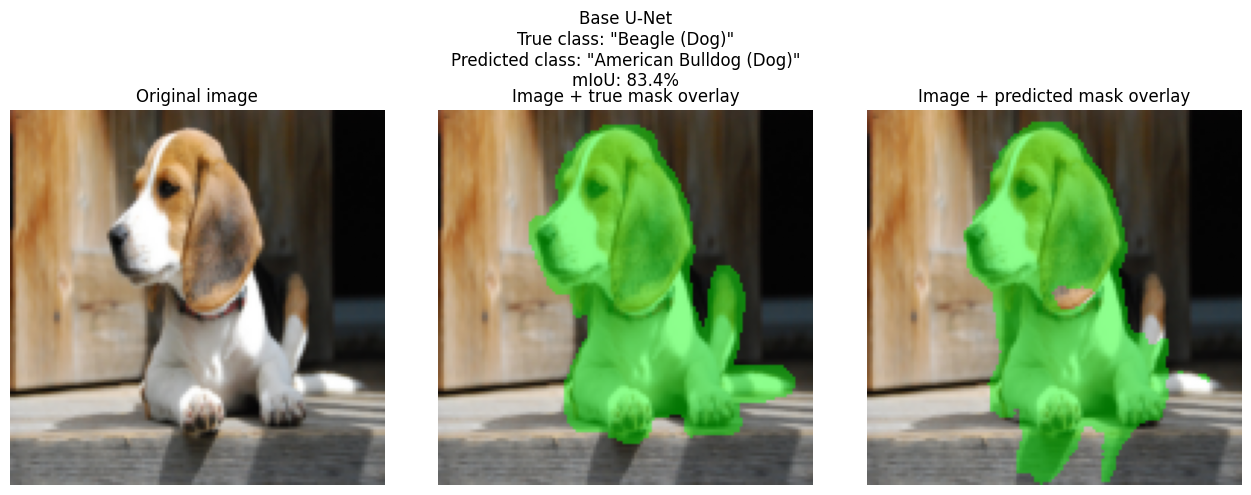

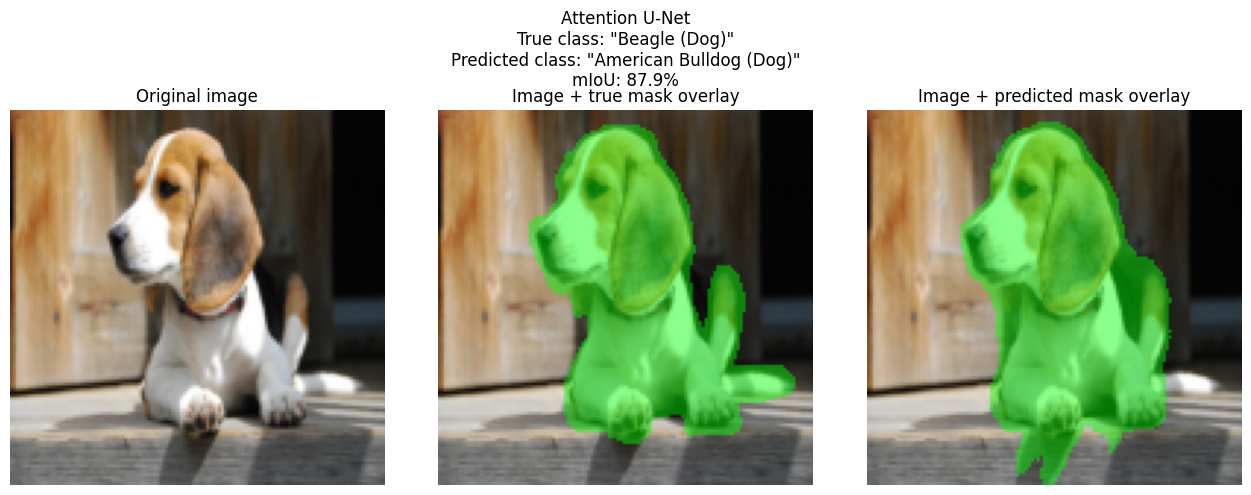

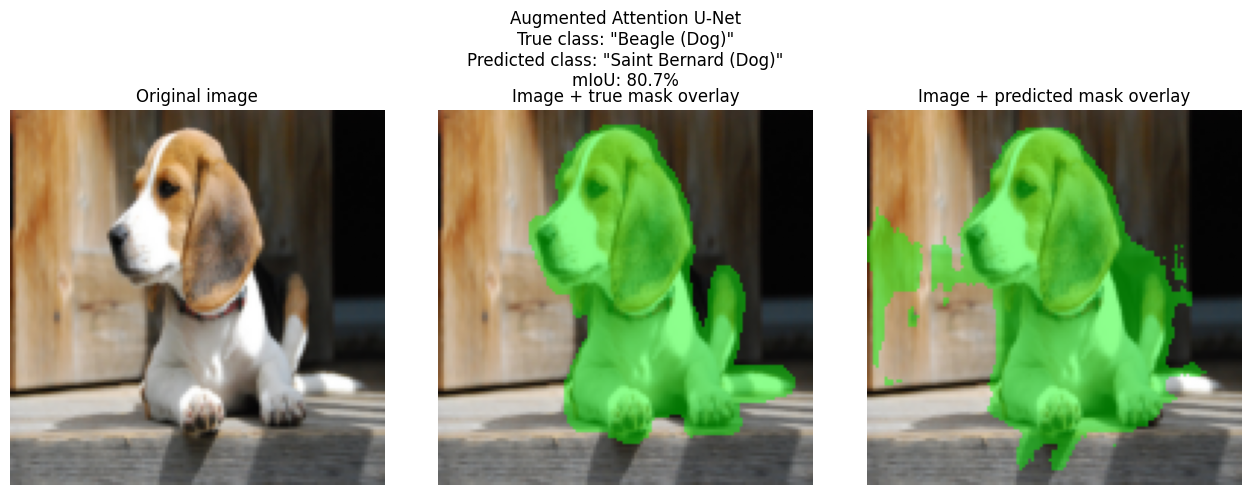

,Model,Predicted class
0,Base U-Net,American Bulldog (Dog)
1,Attention U-Net,American Bulldog (Dog)
2,Augmented Attention U-Net,Saint Bernard (Dog)
3,MobileNetV2,Beagle (Dog)
4,EfficientNet-B0,Beagle (Dog)
5,DenseNet121,Beagle (Dog)


In [ ]:
if ACTIVE_STAGE == "demo":
    for image_path in demo_image_paths:
        run_all_demo_models(image_path)